# 1.3 Annual Sea Level Rankings

```{glue:figure} SL_rankings
:align: center
```
In this notebook, we'll be creating a [table](SL_rankings_results), a [map](SL_rankings_makeamap), and a time series [plot](SL_rankings_timeseries) of sea level rankings at Hawaiian Islands tide gauge stations from 1993-2024. Looking at extreme sea levels by ranking our top events helps us quickly put high and low water levels into historical context with relatively little coding effort. These top 10 events will later be put into a projection context using extreme value analyses (see the [non-stationary GEV](../Annual/1_4_2_1_SL_Extremes_nonstationaryGEV.ipynb) notebook), which will tell us how our historical events compare to, say, a 1-year, 10-year or 20-year return level. We'll also explore the reasons behind these unusually high or low events by examining how different processes contributed over various timescales in the [components](../Annual/1_6_3_contributions_to_daily_sea_level.ipynb) notebook. One interesting thing you might note, in the following exploration, is that the above plot (Nawiliwili on Kauai) shows that high events tend to be lumped together. Compare this plot to other stations in the main Hawaiian Islands (jump to "show code cell output" in [Static Plots](static_plots)), and you'll find that these events tend to "cluster" more in time, as noted by {cite:t}`thompson_statistical_2019`. (The same is not true for Midway, which is dominated by other processes like storm events.)

Download Files:
[Map](https://uhslc.soest.hawaii.edu/jfiedler/SeaLevelIndicators/output/Hawaii_Region_Output/SL_rankings_map.png) |
[Time Series Plot](https://uhslc.soest.hawaii.edu/jfiedler/SeaLevelIndicators/output/Hawaii_Region_Output/SL_rankings_Nawiliwili.png) |
[Table](https://uhslc.soest.hawaii.edu/jfiedler/SeaLevelIndicators/output/Hawaii_Region_Output/SL_top_10_table_Nawiliwili.png)

## Setup

As with previous sections, we first need to import the necessary libraries, establish our input/output directories, and set up some basic plotting rules. We'll do this by running another notebook called [setup](../0_1_setup.ipynb) and import our plotting functions, which will also set our data and output paths. If you have not run the [datawrangling notebook](../0_2_SL_Data_Wrangling.ipynb), you will need to do this before running this notebook. Note that this notebook is also largely a repeat of the [anomaly](../Annual/1_2_SL_anomaly_annual.ipynb) notebook. 

In [2]:
%run ../0_1_setup.ipynb
import sys, pathlib
sys.path.append(str(pathlib.Path('../../functions').resolve()))

from ranking import get_top_ten, get_top_10_table
from tseries_functions import get_station
import plotly.io as pio

# check to make sure that data_dir/rsl_daily_hawaii.nc exists, if not, make warning to run datawrangling notebook
if not (data_dir / 'rsl_hawaii_noaa.nc').exists():
    print('rsl_hawaii_noaa.nc not found in '+ str(data_dir) +  '. Please run the data wrangling notebook first')
else:
    print('rsl_hawaii_noaa.nc found in '+ str(data_dir) +  '. Proceed.')

Using custom paths from config_env.py
Data directory: /Users/jfiedler/Projects/SL_Indicators/data
Output directory: /Users/jfiedler/Projects/SL_Indicators/output
rsl_hawaii_noaa.nc found in /Users/jfiedler/Projects/SL_Indicators/data. Proceed.


### Import data and Clean
Take only locations with data coverage more than 80% of the time, and set all sea level measurements relative to local MHHW, rather than station datum.

In [4]:
#import rsl for the period of record (1993-2024), and drop stations with less than 80% data coverage
with xr.open_dataset(data_dir/ 'rsl_hawaii_noaa.nc') as ds:
    rsl_por = ds.sel(time=slice('1993','2024'))

    data_coverage = rsl_por['sea_level'].count(dim='time')/len(rsl_por.time)

    data_coverage
    #drop all locations with data_coverage less than 80%
    rsl_subset = rsl_por.where(data_coverage>0.80,drop=True)
# make sea level relative to MHHW, and ensure units are in meters
rsl_subset['sea_level'] = rsl_subset['sea_level'] - rsl_subset['MHHW']

# check units in attrs of ds['sea_level'], if in mm make into m. If in m, leave in meters.
if ds['sea_level'].attrs['units'] == 'mm':
    rsl_subset['sea_level'] = rsl_subset['sea_level']/1000
elif ds['sea_level'].attrs['units'] == 'm':
    pass

rsl_subset['sea_level'].attrs['units'] = 'm'

# rename variable long name to sea level relative to MHHW
rsl_subset['sea_level'].attrs['long_name'] = 'sea level, MHHW'


### Resample to monthly
For background plotting purposes. Here we'll extract the mean, min and max of the monthly MHHW sea level.

In [5]:
# get min and max for each month by resampling
rsl_monthly_min = rsl_subset.resample(time='1ME').min()
rsl_monthly_max = rsl_subset.resample(time='1ME').max()
rsl_monthly_mean = rsl_subset.resample(time='1ME').mean()

## Make a Table

Next, we'll use a function ("get_top_10_table") to obtain a table of the top 10 high and low hourly sea level values for a given station. To ensure that we are tracking unique high and low water events, we ensure that the hourly maxima and minima are separated by at least 3 days. The same function will add ONI values to the table, which will come in handy later. These functions are defined in a separate script (python/ranking.py).

Note that because we started this analysis with hourly data, we may not be fully aligned with max/min statistics from other sources. Hourly data will dampen both the minima and maxima due to averaging. Note also that there are other extreme water level rankings that may be offset by a different MHHW datum. Here, we used the 1983-2001 NTDE that is currently available through NOAA CO-OPS. 

```{margin}
For other ranking tables, check out the [NASA Flooding Analysis Tool](https://sealevel.nasa.gov/flooding-analysis-tool/observed-flooding?station-id=1612340) or the [Sea Level Calculator](https://coast.noaa.gov/sealevelcalculator/#/quickview/1612340/extremeWaterLevels&search=eyJhY3RpdmVQYWdlIjoicXVpY2t2aWV3IiwidGlkZVN0YXRpb25JZCI6MTYxMjM0MCwic2VsZWN0ZWRRdWlja1ZpZXciOiJleHRyZW1lV2F0ZXJMZXZlbHMiLCJ0aGVtZSI6ImRhcmsiLCJpc1F1aWNrU2VsZWN0QWN0aXZlIjpmYWxzZSwibWFwTG9jYXRpb24iOnsiY2VudGVyIjpbLTE1Ny44NjQ1MjgsMjEuMzAzMzMyOTk5OTk5OTk1XSwiem9vbSI6MTEuNX0sImFkZHJlc3MiOiJIb25vbHVsdSwgSEkiLCJzdGF0aW9uSXNTZWxlY3RlZCI6dHJ1ZSwiZ2xvYmFsTWVudVZhbHVlcyI6eyJkYXR1bSI6Ik1ISFciLCJ1bml0cyI6ImVuZ2xpc2giLCJkZWNhZGUiOiIyMDMwIiwidmxtIjowLjAwNDMzMDcxMDk5OTk5OTk5OSwidGhyZXNob2xkIjowLjk5NywicHJlRGVmVGhyZXNob2xkIjp7ImxhYmVsIjoiTk9TIE1pbm9yIiwidmFsdWUiOnsiZW5nbGlzaCI6MC45OTcsIm1ldHJpYyI6MC4zMDR9LCJwYXJhbSI6Im5vc19taW5vciJ9LCJkYXlzVGhyZXNob2xkIjpudWxsLCJkYXRhU291cmNlIjoiMjAyMiBUZWNoIFJlcG9ydCIsIm9mZnNldFllYXIiOiIyMDAwIiwic2NlbmFyaW8iOiJJbnRlcm1lZGlhdGUiLCJtc2xUaHJlc2hvbGRJbk1ldHJpYyI6MC42MzMsImNvbnZlcnRlZFZMTSI6MC4xMDk5OTk5OTk5OTk5OTk5OX0sImN1cnJlbnRTdGF0aW9uUHJvcGVydGllcyI6eyJuYW1lIjoiSG9ub2x1bHUsIEhJIiwic3RhdGlvbklEIjoxNjEyMzQwLCJxdiI6WzEsMiwzLDQsNV0sInNsUHJvamVjdGlvblJlZ2lvbk5BU0EiOiJQQUMiLCJiZWdpbkRhdGUiOiIxOTExIiwiZW5kRGF0ZSI6bnVsbCwic3RhdGlvbkxvbiI6LTE1Ny44NjQ1MjgsInN0YXRpb25MYXQiOjIxLjMwMzMzM30sIm5vc1RocmVzaG9sZExheWVyIjoibm9zLW1pbm9yIiwid2F0ZXJMZXZlbCI6IjAiLCJpc01hcEZ1bGwiOmZhbHNlLCJncmlkRGF0YSI6eyJjZWxsRXh0ZW50IjpbXSwiY2xpY2tlZENvb3JkcyI6bnVsbCwiZ3JpZE51bWJlciI6bnVsbCwiUFNNU0xfSUQiOm51bGwsInJlZ2lvbiI6bnVsbH0sImlzU29sb0dyaWRDZWxsIjpmYWxzZSwicmV0cmlldmVkVkxNVmFsdWUiOjAuMTA5OTk5OTk5OTk5OTk5OTksImlzR3JpZExheWVyRGlzcGxheWVkIjp0cnVlLCJzZWxlY3RlZEJhc2VtYXAiOiJzYXRlbGxpdGUiLCJxdjFMZWdlbmQiOnsidGgiOjEsImgiOjEsImloIjoxLCJpIjoxLCJpbCI6MSwibCI6MSwib2UiOjEsInViIjowfSwicXYyTGVnZW5kIjp7ImFkYXQiOjEsImgiOjAsImloIjowLCJpIjowLCJpbCI6MCwibCI6MCwiZCI6MX0sInF2M0xlZ2VuZCI6eyJ0aCI6MSwibXdsIjoxLCJ0UGVyIjoxLCJ0ZW5QZXIiOjEsImZQZXIiOjEsIm5uUGVyIjoxfSwicXY0TGVnZW5kIjp7Im1tIjoxLCJldFBlciI6MSwic1BlciI6MSwibW8iOjEsInJvIjoxLCJsciI6MX0sInF2NUxlZ2VuZCI6eyJkdCI6MSwiZmQiOjEsIm12IjoxLCJhc2MiOjF9LCJxdjVDaGFydEJMZWdlbmQiOnsidHdvUCI6MSwidGVuUCI6MSwiZmlmUCI6MSwibmluUCI6MX19)
```

In [6]:
station_name, station_id = get_station(rsl_subset,'1612340') # Example for Honolulu
top_10_table = get_top_10_table(rsl_subset, station_id, oni_path=str(data_dir / 'climate_indices' / 'oni.csv'))



### Display by rank
Now we'll start to make the table a little more presentable by labeling the columns properly, and organizing events by rank.

In [7]:
# subdivide the data into two columns for max and min
# Filter out the 'max' and 'min' types into separate DataFrames
max_top_10 = top_10_table[top_10_table['type'] == 'max'].reset_index(drop=True)
min_top_10 = top_10_table[top_10_table['type'] == 'min'].reset_index(drop=True)

# make table of highest and lowest values by rank, with columns: rank, highest sea level (m), date, lowest sea level (m), date
top_10_display = pd.DataFrame({'Rank':max_top_10['rank'],
                             'Highest':max_top_10['sea level (m)'].apply(lambda x: float(f"{x:.3g}")),
                             'Highest Date':max_top_10['date'].dt.strftime('%Y-%m-%d %H:%M'),
                             'Highest ONI Mode':max_top_10['ONI Mode'],
                             'Lowest':min_top_10['sea level (m)'].apply(lambda x: float(f"{x:.3g}")),
                             'Lowest Date':min_top_10['date'].dt.strftime('%Y-%m-%d %H:%M'),
                             'Lowest ONI Mode':min_top_10['ONI Mode'],
                             'Zone': 'GMT',
                             'ONI max':max_top_10['ONI'],
                             'ONI min':min_top_10['ONI']})

(SL_rankings_results)=
### Style the table
Now we'll add some style. The table will be colored by the ONI, if the event is classified as an El Nino or La Nina.

In [8]:
top_10_display

,Rank,Highest,Highest Date,Highest ONI Mode,Lowest,Lowest Date,Lowest ONI Mode,Zone,ONI max,ONI min
0,1,0.441,2020-12-15 15:00,La Nina,-0.850,2011-03-11 16:00,La Nina,GMT,-1.19,-0.93
1,2,0.428,2019-12-25 14:00,Neutral,-0.787,2011-03-18 20:00,La Nina,GMT,0.55,-0.93
2,3,0.421,2017-08-21 01:00,Neutral,-0.784,1994-03-29 21:00,Neutral,GMT,-0.11,0.17
3,4,0.417,2021-12-05 15:00,La Nina,-0.767,2010-02-28 20:00,El Nino,GMT,-0.98,1.22
4,5,0.404,2020-07-20 02:00,Neutral,-0.764,2009-05-24 19:00,Neutral,GMT,-0.41,0.01
5,6,0.396,2020-11-15 14:00,La Nina,-0.762,2010-04-27 19:00,Neutral,GMT,-1.27,0.35
6,7,0.391,2017-06-24 02:00,Neutral,-0.760,2002-02-26 07:00,Neutral,GMT,0.31,0.03
7,8,0.391,2020-10-19 16:00,La Nina,-0.758,2011-12-25 07:00,La Nina,GMT,-1.17,-1.04
8,9,0.383,2020-07-05 02:00,Neutral,-0.758,2013-04-25 19:00,Neutral,GMT,-0.41,-0.30
9,10,0.382,2019-08-02 03:00,Neutral,-0.757,1998-07-06 17:00,La Nina,GMT,0.14,-0.78


In [9]:
# # Define a function that returns styles for both 'Highest' and 'Lowest' based on respective ONI Modes
# # Normalize the ONI values
import matplotlib.colors as mcolors
norm = mcolors.Normalize(vmin=-3, vmax=3)

# Define the color maps
cmap = sns.color_palette('coolwarm', as_cmap=True)

def style_oni_based(row):
    styles = {}
    # Color for 'Highest' based on 'Highest ONI Mode'
    if row['Highest ONI Mode'] == 'El Nino':
        styles['Highest'] = f'background-color: {mcolors.rgb2hex(cmap(norm(row["ONI max"])))}'
    elif row['Highest ONI Mode'] == 'La Nina':
        styles['Highest'] = f'background-color: {mcolors.rgb2hex(cmap(norm(row["ONI max"])))}'
    else:
        styles['Highest'] = 'color: black'  # Neutral or undefined
    # Color for 'Lowest' based on 'Lowest ONI Mode'
    if row['Lowest ONI Mode'] == 'El Nino':
        styles['Lowest'] = f'background-color: {mcolors.rgb2hex(cmap(norm(row["ONI min"])))}'
    elif row['Lowest ONI Mode'] == 'La Nina':
        styles['Lowest'] = f'background-color: {mcolors.rgb2hex(cmap(norm(row["ONI min"])))}'
    else:
        styles['Lowest'] = 'color: black'  # Neutral or undefined
    return pd.Series(styles)    

# Define the table style
styles_col = [
    {'selector': 'th', 'props': [('border-bottom', '2px solid #000'), ('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': '.dataframe th:nth-child(3)', 'props': [('padding-right', '100px')]}]

# Apply the styling function to the DataFrame
top_10_d = top_10_display.style.\
                            apply(style_oni_based, axis=1).\
                            hide(subset=['Highest ONI Mode', 'Lowest ONI Mode','ONI max','ONI min'], axis=1).\
                            hide().\
                            set_table_attributes(styles_col)


# Display the styled DataFrame



tablename = 'SL_top_10_table_' + station_name + '.csv'
# save table to output folder
top_10_display.to_csv(output_dir / tablename, index=False)

top_10_d

Rank,Highest,Highest Date,Lowest,Lowest Date,Zone
1,0.441000,2020-12-15 15:00,-0.850000,2011-03-11 16:00,GMT
2,0.428000,2019-12-25 14:00,-0.787000,2011-03-18 20:00,GMT
3,0.421000,2017-08-21 01:00,-0.784000,1994-03-29 21:00,GMT
4,0.417000,2021-12-05 15:00,-0.767000,2010-02-28 20:00,GMT
5,0.404000,2020-07-20 02:00,-0.764000,2009-05-24 19:00,GMT
6,0.396000,2020-11-15 14:00,-0.762000,2010-04-27 19:00,GMT
7,0.391000,2017-06-24 02:00,-0.760000,2002-02-26 07:00,GMT
8,0.391000,2020-10-19 16:00,-0.758000,2011-12-25 07:00,GMT
9,0.383000,2020-07-05 02:00,-0.758000,2013-04-25 19:00,GMT
10,0.382000,2019-08-02 03:00,-0.757000,1998-07-06 17:00,GMT


In [10]:
#make this a pretty table with great_tables
from great_tables import GT, md, html

# replace all spaces with underscores in top_10_display column names
top_10_display.columns = top_10_display.columns.str.replace(' ', '_')

outFilename = 'SL_top_10_table_' + station_name + '.png'
outFilepath = output_dir / outFilename

# Convert the DataFrame to a great_table
(
    GT(top_10_display)
    .tab_header(title='Top 10 Sea Level Events', subtitle='Station: '+station_name)
    .tab_spanner(label='HIGHEST', columns=['Highest', 'Highest_Date', 'Highest_ONI_Mode'])
    .tab_spanner(label='LOWEST', columns=['Lowest', 'Lowest_Date', 'Lowest_ONI_Mode'])
    .cols_hide(columns=['ONI_max','ONI_min','Zone'])
    .cols_align('center')
    .cols_label(Highest=html('Water Level <br>(m, MHHW)'), Highest_Date='Date', Highest_ONI_Mode='ONI Mode',
                Lowest=html('Water Level <br>(m, MHHW)'), Lowest_Date='Date', Lowest_ONI_Mode='ONI Mode')
                .tab_source_note(source_note='Source: NOAA CO-OPS Hourly Water Level, https://psl.noaa.gov/data/correlation/oni.data')
    .save(outFilepath)
)

GT(_tbl_data=   Rank  Highest      Highest_Date Highest_ONI_Mode  Lowest       Lowest_Date  \
0     1    0.441  2020-12-15 15:00          La Nina  -0.850  2011-03-11 16:00   
1     2    0.428  2019-12-25 14:00          Neutral  -0.787  2011-03-18 20:00   
2     3    0.421  2017-08-21 01:00          Neutral  -0.784  1994-03-29 21:00   
3     4    0.417  2021-12-05 15:00          La Nina  -0.767  2010-02-28 20:00   
4     5    0.404  2020-07-20 02:00          Neutral  -0.764  2009-05-24 19:00   
5     6    0.396  2020-11-15 14:00          La Nina  -0.762  2010-04-27 19:00   
6     7    0.391  2017-06-24 02:00          Neutral  -0.760  2002-02-26 07:00   
7     8    0.391  2020-10-19 16:00          La Nina  -0.758  2011-12-25 07:00   
8     9    0.383  2020-07-05 02:00          Neutral  -0.758  2013-04-25 19:00   
9    10    0.382  2019-08-02 03:00          Neutral  -0.757  1998-07-06 17:00   

  Lowest_ONI_Mode Zone  ONI_max  ONI_min  
0         La Nina  GMT    -1.19    -0.93  
1         La Nina  GMT     0.55    -0.93  
2         Neutral  GMT    -0.11     0.17  
3         El Nino  GMT    -0.98     1.22  
4         Neutral  GMT    -0.41     0.01  
5         Neutral  GMT    -1.27     0.35  
6         Neutral  GMT     0.31     0.03  
7         La Nina  GMT    -1.17    -1.04  
8         Neutral  GMT    -0.41    -0.30  
9         La Nina  GMT     0.14    -0.78  , _body=<great_tables._gt_data.Body object at 0x198fb4e10>, _boxhead=Boxhead([ColInfo(var='Rank', type=<ColInfoTypeEnum.default: 1>, column_label='Rank', column_align='center', column_width=None), ColInfo(var='Highest', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Water Level <br>(m, MHHW)'), column_align='center', column_width=None), ColInfo(var='Highest_Date', type=<ColInfoTypeEnum.default: 1>, column_label='Date', column_align='center', column_width=None), ColInfo(var='Highest_ONI_Mode', type=<ColInfoTypeEnum.default: 1>, column_label='ONI Mode', column_align='center', column_width=None), ColInfo(var='Lowest', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Water Level <br>(m, MHHW)'), column_align='center', column_width=None), ColInfo(var='Lowest_Date', type=<ColInfoTypeEnum.default: 1>, column_label='Date', column_align='center', column_width=None), ColInfo(var='Lowest_ONI_Mode', type=<ColInfoTypeEnum.default: 1>, column_label='ONI Mode', column_align='center', column_width=None), ColInfo(var='Zone', type=<ColInfoTypeEnum.hidden: 4>, column_label='Zone', column_align='center', column_width=None), ColInfo(var='ONI_max', type=<ColInfoTypeEnum.hidden: 4>, column_label='ONI_max', column_align='center', column_width=None), ColInfo(var='ONI_min', type=<ColInfoTypeEnum.hidden: 4>, column_label='ONI_min', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x195dd7610>, _spanners=Spanners([SpannerInfo(spanner_id='HIGHEST', spanner_level=0, spanner_label='HIGHEST', spanner_units=None, spanner_pattern=None, vars=['Highest', 'Highest_Date', 'Highest_ONI_Mode'], built=None), SpannerInfo(spanner_id='LOWEST', spanner_level=0, spanner_label='LOWEST', spanner_units=None, spanner_pattern=None, vars=['Lowest', 'Lowest_Date', 'Lowest_ONI_Mode'], built=None)]), _heading=Heading(title='Top 10 Sea Level Events', subtitle='Station: Honolulu', preheader=None), _stubhead=None, _source_notes=['Source: NOAA CO-OPS Hourly Water Level, https://psl.noaa.gov/data/correlation/oni.data'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x198fb42d0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right

(SL_rankings_timeseries)=
## Make Timeseries Plots
Now we'll plot this data up in the time domain.

### Interactive Plots
This version is interactive. Bad for making pdf reports though.

In [11]:
import plotly.graph_objects as go

def make_plotlyFigure(rsl_monthly_mean, rsl_monthly_max, rsl_monthly_min, top_10_table, rsl_subset, station_id):
    figly = go.Figure()
    top_10_table = get_top_10_table(rsl_subset, station_id, oni_path=str(data_dir / 'climate_indices' / 'oni.csv'))
    
    # Select data for the current station
    max_sl = rsl_monthly_max['sea_level'].sel(station_id=station_id)
    min_sl = rsl_monthly_min['sea_level'].sel(station_id=station_id)
    mean_sl = rsl_monthly_mean['sea_level'].sel(station_id=station_id)

    x = mean_sl.time - np.timedelta64(15, 'D')  # add 15 days to make the line in the middle of the month


    # Drop NaN values and get the corresponding time coordinates
    max_sl_clean = max_sl.dropna(dim='time')
    min_sl_clean = min_sl.dropna(dim='time')
    mean_sl_clean = mean_sl.dropna(dim='time')


    # Add traces
    figly.add_trace(go.Scatter(x=x, y=max_sl_clean, 
                    mode='lines', line_color='rgba(0,176,246,0.2)', name='Monthly Max'))

    figly.add_trace(go.Scatter(x=x, y=min_sl_clean, 
                    mode='lines', line_color='rgba(0,176,246,0.2)', fill='tonexty', 
                    fillcolor='rgba(0,176,246,0.2)', name='Range (Monthly Max/Min)'))

    figly.add_trace(go.Scatter(x=x, y=mean_sl_clean, 
                    mode='lines', line_color='rgba(0,176,246,1)', name='Monthly Mean'))

    # Add El Niño markers
    figly.add_trace(go.Scatter(x=top_10_table[top_10_table['ONI Mode']=='El Nino'].date,
                                y=top_10_table[top_10_table['ONI Mode']=='El Nino']['sea level (m)'],
                                mode='markers', marker=dict(color='red', size=12, symbol='star'), name='El Niño',
                                hoverinfo='none'))
    
    # Add La Niña markers
    figly.add_trace(go.Scatter(x=top_10_table[top_10_table['ONI Mode']=='La Nina'].date,
                                y=top_10_table[top_10_table['ONI Mode']=='La Nina']['sea level (m)'],
                                mode='markers', marker=dict(color='blue', size=12, symbol='circle'), name='La Niña',
                                hoverinfo='none'))
    
    # Add highest/lowest events markers
    figly.add_trace(go.Scatter(x=top_10_table.date, y=top_10_table['sea level (m)'], 
                                mode='markers', marker=dict(color='orange', size=6, symbol='circle'), name='Highest/Lowest Events',
                                hovertemplate='%{x}, %{y:.2f} m<extra></extra>'))
    
    # Update layout
    figly.update_layout(
        title=str(station_name),
        xaxis_title='Time',
        yaxis_title=f"{rsl_subset['sea_level'].attrs['long_name']} [{rsl_subset['sea_level'].attrs['units']}]",
        showlegend=True,
        # width=500,  # Set figure width
        # height=400,  # Set figure height
        autosize=True,  # Turn off autosize
        plot_bgcolor='white',
        xaxis=dict(showgrid=True, gridwidth=0.5, gridcolor='rgb(200,200,200)', range=['1993-01-01', '2024-12-31']),
        yaxis=dict(showgrid=True, gridwidth=0.5, gridcolor='rgb(200,200,200)'),
        legend=dict(
            orientation='h',  # Horizontal orientation
            y=-0.3,  # Position below the plot
            x=0.5,  # Centered horizontally
            xanchor='center',
            yanchor='top',
            font=dict(size=10)  # Smaller font size for legend items
        ),
        margin=dict(l=50, r=50, t=50, b=100),  # Increase bottom margin to make room for the legend
        title_x=0.5,  # Center the title
        title_font_size=20,
        title_font_family='Arial',
        title_font_color='black'
    )


    
    # figly.show()
    return figly

A note: the plotly plot will not render in the jupyter book build, because the original data to build it is stored elsewhere (not on github). If you are replicating this notebook, it should work fine for you. In the meantime, the pre-built html is available.

In [14]:
figly = make_plotlyFigure(rsl_monthly_mean, 
        rsl_monthly_max, rsl_monthly_min, 
        top_10_table, rsl_subset,station_id)

# change size of the plot
# figly.update_layout(autosize=True)
figly.update_layout(width=800, height=500,autosize=False)
# save the figure to the output folder
figname = 'SL_top_10_plot_' + station_name + '.html'

# # remove commas from figname
# figname = figname.replace(', ','_')
# matrix_dir = Path('../../matrix/plotly')
# pio.write_html(figly, str(matrix_dir / figname), auto_open=False)

figly

In [15]:
from IPython.display import IFrame
IFrame(src='https://uhslc.soest.hawaii.edu/jfiedler/SeaLevelIndicators/plotly/SL_top_10_plot_Honolulu.html', width=800, height=500, align='center')

```{note}
Note: If the rendering doesn't work here for the interactive plot: visit the [pre-made plot](https://uhslc.soest.hawaii.edu/jfiedler/SeaLevelIndicators/plotly/SL_top_10_plot_Honolulu.html) to explore the data in more detail.
```

(static_plots)=
### Static Plots
Plotting them all so we can decide what to do with them. Click "show code cell output" to see all stations.

In [17]:
ID_list

[1617760, 1619910, 1617433, 1612480, 1615680, 1612340, 1611400]

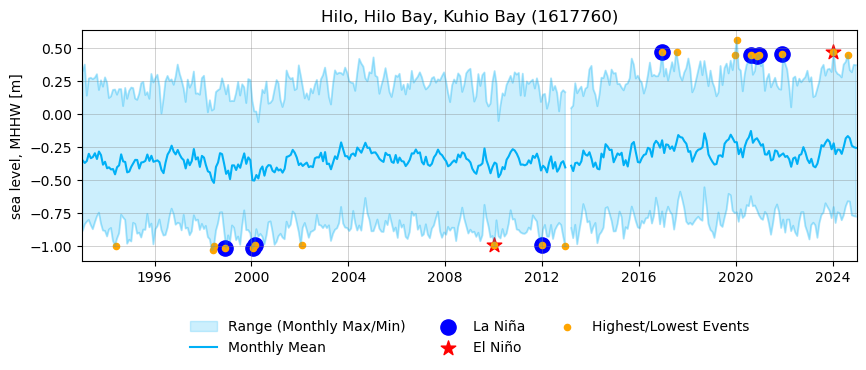

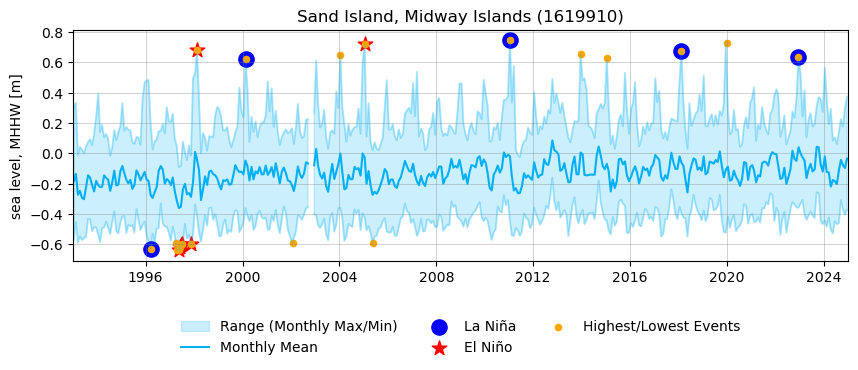

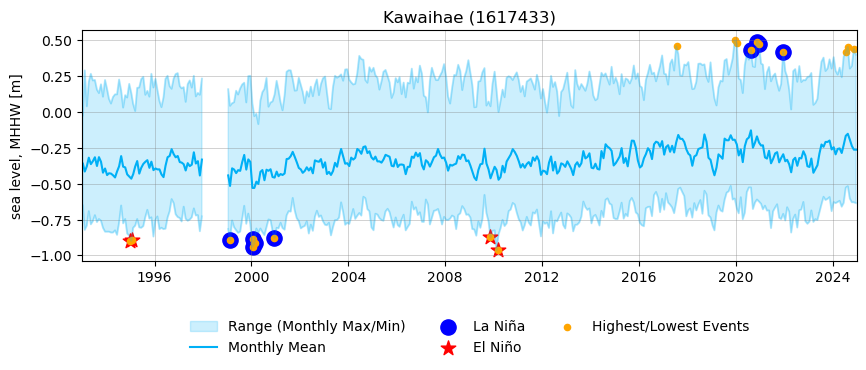

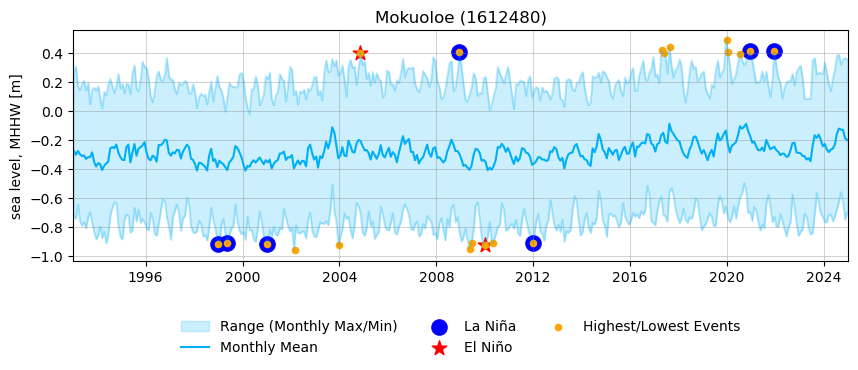

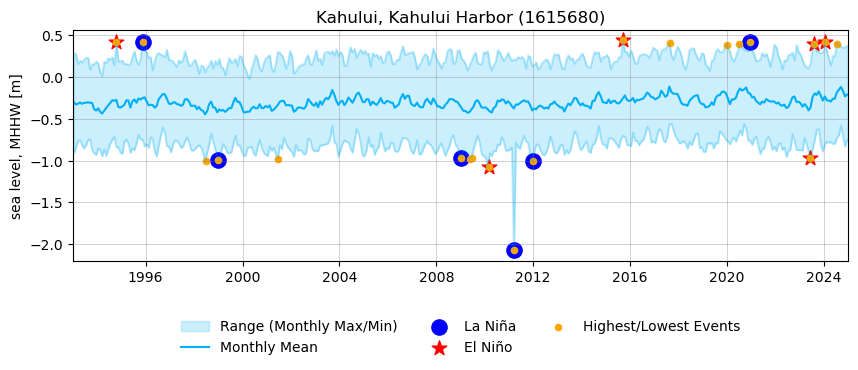

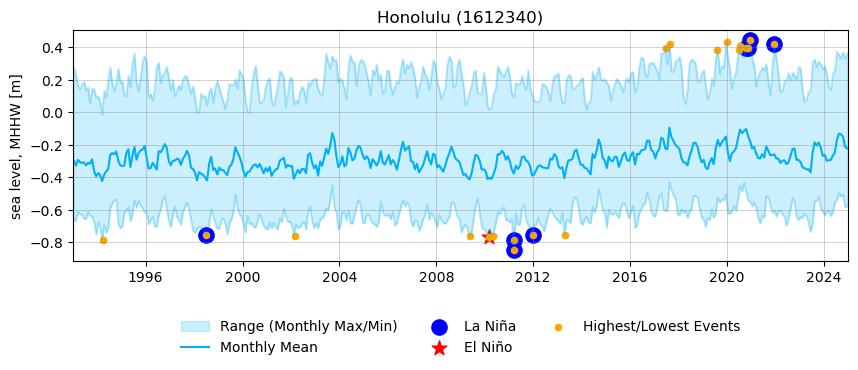

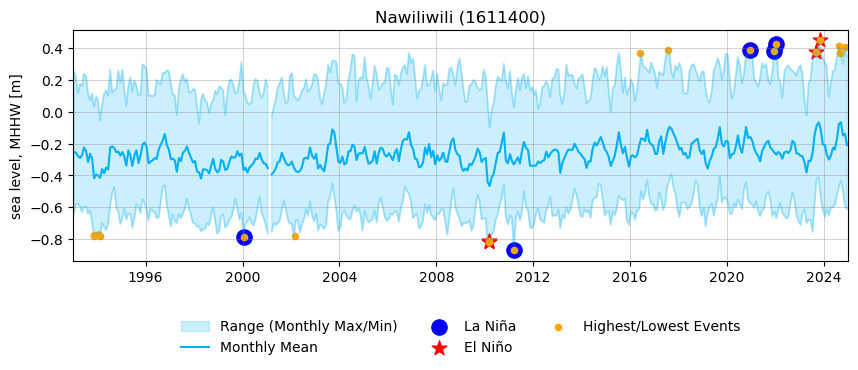

In [20]:
# static version

# Plot configuration
ID_list = rsl_subset['station_id'].values.tolist()
# loop through all the records
for ID in ID_list:
    station_name, station_id = get_station(rsl_subset,ID)
    top_10_table = get_top_10_table(rsl_subset, station_id, oni_path=str(data_dir / 'climate_indices' / 'oni.csv'))
    # get top_10_table for each record
    fig,ax = plt.subplots(1,1,figsize=(10,3))

    x = rsl_monthly_mean.time - np.timedelta64(15,'D') # add 15 days to make the line in the middle of the month

    # station_name = str(rsl_subset['station_name'].sel(station_id=station_id).values)
    ax.set_title(station_name + ' (' + str(station_id) + ')')
    ax.set_ylabel(f'{rsl_subset["sea_level"].attrs["long_name"]} [{rsl_subset["sea_level"].attrs["units"]}]')
    
    # Plot the max, min, and mean lines
    # Plot the max, min, and mean lines
    ax.plot(x, rsl_monthly_max['sea_level'].sel(station_id=station_id), color=(0/255, 176/255, 246/255, 0.2))
    ax.plot(x, rsl_monthly_min['sea_level'].sel(station_id=station_id), color=(0/255, 176/255, 246/255, 0.2))
    ax.fill_between(x, rsl_monthly_max['sea_level'].sel(station_id=station_id), 
                     rsl_monthly_min['sea_level'].sel(station_id=station_id), color=(0/255, 176/255, 246/255, 0.2), label='Range (Monthly Max/Min)')
    ax.plot(x, rsl_monthly_mean['sea_level'].sel(station_id=station_id), color=(0/255, 176/255, 246/255, 1), label='Monthly Mean')

    # Plot the markers for La Niña, El Niño, and other events
    ax.scatter(top_10_table[top_10_table['ONI Mode']=='La Nina'].date, top_10_table[top_10_table['ONI Mode']=='La Nina']['sea level (m)'], color='blue', s=120, label='La Niña', marker='o')
    ax.scatter(top_10_table[top_10_table['ONI Mode']=='El Nino'].date, top_10_table[top_10_table['ONI Mode']=='El Nino']['sea level (m)'], color='red', s=120, label='El Niño', marker='*')
    ax.scatter(top_10_table.date, top_10_table['sea level (m)'], color='orange', s=20, label='Highest/Lowest Events', marker='o')
    
    # Setting the x-axis limits
    ax.set_xlim(pd.Timestamp('1993-01-01'), pd.Timestamp('2024-12-31'))
    
    # Improve the appearance
    ax.grid(True, color='gray', alpha=0.5 ,linewidth=0.5)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=10)
    
    
    # Save the plot to a file
    figname = 'SL_rankings_' + str(rsl_subset['station_name'].sel(station_id=station_id).values) + '.png'
    fig.savefig(output_dir / figname, dpi=300, bbox_inches='tight')


glue("SL_rankings",fig,display=False)

```{glue:figure} SL_rankings
:name: "SL_rankings"

This is a static version of the previous figure, which can be used for print (or static websites).
```

(SL_rankings_makeamap)=
## Create a map
Now we'll make a map of this information, using max and min at each station. First we need to organize our data.

In [21]:
# concatenate the top 10 values for each record
top_10_table_all = pd.concat([get_top_10_table(rsl_subset, ID, oni_path=str(data_dir / 'climate_indices' / 'oni.csv')) for ID in ID_list])

#ensure station_id is an integer
top_10_table_all['station_id'] = top_10_table_all['station_id'].astype(int)

# max_SL is all rank 1, with type max
max_SL = top_10_table_all[top_10_table_all['rank'] == 1 & (top_10_table_all['type'] == 'max')].copy()

# sort by station_id
max_SL = max_SL.sort_values('station_id')
rsl_subset = rsl_subset.sortby('station_id')

max_SL.loc[:, 'lat'] = rsl_subset['lat'].values
max_SL.loc[:, 'lon'] = rsl_subset['lon'].values



# min SL is all rank 1, with type min
min_SL = top_10_table_all[top_10_table_all['rank'] == 1 & (top_10_table_all['type'] == 'min')].copy()



min_SL.loc[:, 'lat'] = rsl_subset['lat'].values
min_SL.loc[:, 'lon'] = rsl_subset['lon'].values

Next, we'll plot it up.

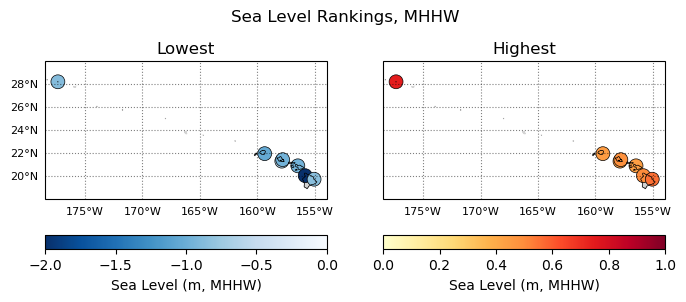

In [22]:
import warnings # import warnings to suppress warnings in cartopy
warnings.filterwarnings("ignore",category=RuntimeWarning, message="invalid value encountered in create_collection")

# define vmin and vmax variables
vmin = 0.2
vmax = 0.8

# open the cmems data
cmems = xr.open_dataset(data_dir / 'cmems_L4_SSH_0.125deg_1993_2025hawaii.nc')

xlims = [cmems.longitude.min(), cmems.longitude.max()]
ylims = [cmems.latitude.min(), cmems.latitude.max()]

# get max value for each station
crs = ccrs.PlateCarree()

fig, axs = plt.subplots(1, 2, figsize=(8, 3), 
                        subplot_kw={'projection': ccrs.PlateCarree()})
# make ax,fig


maxplt = axs[1].scatter(max_SL['lon'], max_SL['lat'], transform=crs, s=100, 
           c=max_SL['sea level (m)'], vmin=0, vmax=1, cmap='YlOrRd',
           linewidth=0.5, edgecolor='black')

minplt = axs[0].scatter(min_SL['lon'], min_SL['lat'], transform=crs, s=100, 
           c=min_SL['sea level (m)'], vmin=-2, vmax=0, cmap='Blues_r',
           linewidth=0.5, edgecolor='black')

plt.colorbar(minplt,ax=axs[0],label='Sea Level (m, MHHW)', location='bottom')           
plt.colorbar(maxplt,ax=axs[1],label='Sea Level (m, MHHW)', location='bottom') 

    
for i, ax in enumerate(axs.flat):
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, color='lightgrey')
    #add grid
    gl = ax.gridlines(draw_labels=False, linestyle=':', color='black',
                      alpha=0.5,xlocs=ax.get_xticks(),ylocs=ax.get_yticks())
    if i>=0:
        gl.bottom_labels = True
    if i==0:
        gl.left_labels = True
    #make all labels tiny
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

# add title
axs[0].set_title('Lowest')
axs[1].set_title('Highest')

# adjust ylims
axs[0].set_ylim(18,30)
axs[1].set_ylim(18,30)

# super title
fig.suptitle('Sea Level Rankings, MHHW')

#eliminate white space at top
fig.subplots_adjust(top=0.9)

glue("SL_rankings_map",fig,display=False)

# save the figure
figname = 'SL_rankings_map.png'
fig.savefig(output_dir / figname, dpi=300, bbox_inches='tight')

```{glue:figure} SL_rankings_map
:name: "SL_rankings_map"

Lowest and highest observed sea levels, relative to MHHW. 
```

## Citations

```{bibliography}
:style: plain
:filter: docname in docnames
```